# Example: Treasury Bill Pricing, Interest Rate Risk, and Term to Maturity
In this example, we use Treasury-bill auction data from October 2022 to the present and a controlled pricing simulation to examine Malkiel's result that longer-maturity fixed payments are more sensitive to a given yield change.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
>
> * __Price zero-coupon Treasury bills:__ Apply a stated discounting model to a bill's face value and term to maturity. Explain how the assumed compounding convention enters the computed price.
> * __Compare interest-rate sensitivity across maturities:__ Simulate and visualize how identical proportional scalings of each bill's reported investment rate change the prices of a shorter- and a longer-maturity bill. Interpret the resulting percentage price changes as a test of Malkiel's maturity theorem.
> * __Check model prices against data:__ Compare the computed price with the reported auction price for a selected bill. Identify the settlement and day-count conventions that the official Treasury quotation requires.

We will investigate how maturity changes a bill's exposure to interest-rate risk.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
# Load the notebook environment and local pricing helpers.
include(joinpath(@__DIR__, "Include.jl"));

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We load the Treasury bill auction records using [the `MyTreasuryBillDataSet(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTreasuryBillDataSet) exported by the `VLQuantitativeFinancePackage`, which returns them as [a `DataFrame` instance](https://dataframes.juliadata.org/stable/). We store the data in the `dataset::DataFrame` variable. Cash-management bills are omitted by default, so every record carries a term quoted in weeks.

In [2]:
# Load Treasury bill auction records from October 2022 onward.
dataset = MyTreasuryBillDataSet()

Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,High Rate,Investment Rate
,String15,String7,String7,String15,String15,String15,Float64,Float64,Float64
1,912797WC7,Bill,26-Week,08/24/2026,08/27/2026,02/25/2027,98.0839,0.0379,0.03918
2,912797SU2,Bill,13-Week,08/24/2026,08/27/2026,11/27/2026,99.0506,0.03715,0.03803
3,912797VM6,Bill,8-Week,08/20/2026,08/25/2026,10/20/2026,99.4314,0.03655,0.03727
4,912797VD6,Bill,4-Week,08/20/2026,08/25/2026,09/22/2026,99.7169,0.0364,0.03701
5,912797WG8,Bill,17-Week,08/19/2026,08/25/2026,12/22/2026,98.7604,0.0375,0.0385
6,912797SA6,Bill,6-Week,08/18/2026,08/20/2026,10/01/2026,99.5747,0.03645,0.03711
7,912797UZ8,Bill,13-Week,08/17/2026,08/20/2026,11/19/2026,99.0609,0.03715,0.03802
8,912797TV9,Bill,26-Week,08/17/2026,08/20/2026,02/18/2027,98.089,0.0378,0.03907
9,912797VL8,Bill,8-Week,08/13/2026,08/18/2026,10/13/2026,99.4299,0.03665,0.03737


Next, let's store the number of records in our auction dataset in the `number_of_bills::Int64` variable:

In [3]:
# Count the records so a random index can span every available auction row.
number_of_bills = nrow(dataset)

1145

___

## Task 1: Compute and Verify the Price of a Random Treasury Bill
Before we do any sensitivity calculations, let's double-check our Treasury pricing implementation. 

In this task, we compute the price of a random T-bill. First, let's construct an instance of the [`DiscreteCompoundingModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.DiscreteCompoundingModel) and store this discount model in the `discount_model::DiscreteCompoundingModel` variable.

> __Dispatch:__ The [`DiscreteCompoundingModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.DiscreteCompoundingModel) has no data associated with it. Instead, it is used [by the Julia multiple dispatch system](https://docs.julialang.org/en/v1/manual/methods/#Methods) so that we call the correct pricing methods later.

Let's build our discount model:

In [4]:
# Use discrete compounding for the classroom zero-coupon pricing model.
discount_model = DiscreteCompoundingModel();

Next, select a bill from the `dataset` by randomly selecting an index from `1...number_of_bills` using the [built-in Julia rand function](https://docs.julialang.org/en/v1/stdlib/Random/#Base.rand), and store the index in the `random_bill_index::Int64` variable:

In [5]:
# Select one auction row for quotation-price validation.
random_bill_index = rand(1:number_of_bills)
println("Selected bill: $(random_bill_index)")

Selected bill: 80


What is the data on this bill?

In [6]:
# Display every auction field for the selected bill.
dataset[random_bill_index,:]

Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,High Rate,Investment Rate
,String15,String7,String7,String15,String15,String15,Float64,Float64,Float64
80,912797VE4,Bill,17-Week,05/27/2026,06/02/2026,09/29/2026,98.8001,0.0363,0.03725


### Check: Verify the computed price of a random T-bill
Next, let's build a zero-coupon Treasury bill model, an instance of [the `MyUSTreasuryZeroCouponBondModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.MyUSTreasuryZeroCouponBondModel) using [a custom `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.build-Tuple{Type{MyUSTreasuryZeroCouponBondModel},%20NamedTuple}). 

> __Build:__ The [`build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.build-Tuple{Type{MyUSTreasuryZeroCouponBondModel},%20NamedTuple}) requires two arguments: the type of thing we want to build, and [a NamedTuple](https://docs.julialang.org/en/v1/base/base/#Core.NamedTuple) holding data needed to construct the thing we want to build. In this case, we pass the `par` value of the T-bill and the `n` argument, i.e., the number of compounding periods per year. We set the duration `T` and `rate` fields using data from the randomly selected bill, and use the short-cut syntax to compute the price. 

Save the updated model in the `zero_coupon_model::MyUSTreasuryZeroCouponBondModel` variable.

That model uses a generic semiannual equivalent-yield convention, which is not the rule the Treasury quotes bills under, so we separately reconstruct the official price with [the `treasury_bill_price_from_investment_rate(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/), which applies the day-count and settlement conventions of 31 CFR Part 356 to the bill's actual issue and maturity dates. We store that value in the `treasury_quotation_price::Float64` variable.

In [7]:
# Build a classroom zero-coupon model from the selected term and investment rate.
zero_coupon_model = build(MyUSTreasuryZeroCouponBondModel, (
    par = 100.0, n = 2, # semiannual classroom compounding convention

    ### BEGIN SOLUTION    
    T = dataset[random_bill_index, Symbol("Security Term")] |> String |> securityterm, # convert the term label to years
    rate =  dataset[random_bill_index, Symbol("Investment Rate")]
    ### END SOLUTION    

)) |> discount_model;

# Reconstruct the official Treasury quotation from the actual issue and maturity dates.
treasury_quotation_price = let
    row = dataset[random_bill_index, :];
    issue_date = Date(row[Symbol("Issue Date")], dateformat"mm/dd/yyyy");
    maturity_date = Date(row[Symbol("Maturity Date")], dateformat"mm/dd/yyyy");
    treasury_bill_price_from_investment_rate(zero_coupon_model.par,
        row[Symbol("Investment Rate")], issue_date, maturity_date)
end;

Did we get the same price as that recorded at auction? We compare the quotation price, because that is the convention the auction result is reported under.

> __Test:__ If two values are within some relative tolerance `rtol` of each other, the [isapprox function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox) returns `true`; otherwise, it returns `false`. When the [isapprox function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox) is combined with the [@assert macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert), a `false` result generates an [AssertionError](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError). Thus, we have a simple test for equality that works well for floating-point numbers.

So, how did we do?

In [8]:
# Check that the date-based Treasury quotation reproduces the recorded auction price.
let
    auction_price = dataset[random_bill_index, :Price];
    @assert isapprox(auction_price, treasury_quotation_price; rtol=1e-4)
end

___

## Task 2: Compute the sensitivity of the T-bill price to interest rate and term to maturity
In this task, let's test Malkiel's Theorem 2 by simulating prices as a function of interest rate and term to maturity. 

> __Idea:__ Create models for two bills $i$ and $j$ from the `dataset`. Bills $i$ and $j$ should have a significant difference in term to maturity, for example, `4 weeks` versus `52 weeks`. Then simulate how these instruments' prices change as we vary the yield by the same percentage.

Let's start with the short-duration bill. Randomly select the index of a `4-Week` Treasury bill, and save this index in the `i::Int64` variable. 

> __Filter:__ We can select data from `dataset` using [the `filter(...)` function exported by the DataFrames.jl package](https://dataframes.juliadata.org/stable/lib/functions/#Base.filter). The [`filter(...)` function](https://dataframes.juliadata.org/stable/lib/functions/#Base.filter) takes a function as its first argument and a data frame `df` as its second argument. It returns a data frame containing only the rows from `df` for which `func` returns `true`.

Let's pull out a random short-duration Treasury bill, e.g., a `4-Week` term:

In [9]:
# Select one 4-week auction record for the short-maturity comparison.
short_duration_dataset = filter(Symbol("Security Term") => x-> x == "4-Week", dataset)
i = nrow(short_duration_dataset) |> x-> rand(1:x);
short_duration_dataset[i,:]

Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,High Rate,Investment Rate
,String15,String7,String7,String15,String15,String15,Float64,Float64,Float64
67,912797PS0,Bill,4-Week,05/15/2025,05/20/2025,06/17/2025,99.6718,0.0422,0.04293


Next, build [a `MyUSTreasuryZeroCouponBondModel` instance](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.MyUSTreasuryZeroCouponBondModel) to model the randomly selected `4-Week` Treasury bill, save this model in the `short_duration_model` variable, and then compute the price using the short-cut syntax:

In [10]:
# Build and price the selected short-maturity bill.
short_duration_model = build(MyUSTreasuryZeroCouponBondModel, (
    
    ### BEGIN SOLUTION    
    par = 100, n = 2, # semiannual classroom compounding convention
    T = short_duration_dataset[i, Symbol("Security Term")] |> String |> securityterm,
    rate = short_duration_dataset[i, Symbol("Investment Rate")],
    ### END SOLUTION
        
)) |> discount_model; # Populate the model price with the selected discount convention.

Check: does the quotation price for the short-duration bill match the auction record?

> __Test:__ If two values are within some relative tolerance `rtol` of each other, the [isapprox function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox) returns `true`; otherwise, it returns `false`. When the [isapprox function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox) is combined with the [@assert macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert), a `false` result generates an [AssertionError](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError). Thus, we have a simple test for equality that works well for floating-point numbers.

So how did we do?

In [11]:
# Validate the selected short bill against its official date-based quotation.
let
    # Check that the date-based quotation matches the selected short-bill record.
    row = short_duration_dataset[i, :];
    quotation_price = treasury_bill_price_from_investment_rate(short_duration_model.par,
        row[Symbol("Investment Rate")],
        Date(row[Symbol("Issue Date")], dateformat"mm/dd/yyyy"),
        Date(row[Symbol("Maturity Date")], dateformat"mm/dd/yyyy"));
    @assert isapprox(quotation_price, row[:Price], rtol = 1e-4)
end

### Build a long-duration bill model
Select the index of a random `52-Week` Treasury bill, and save this index in the `j::Int64` variable.

In [12]:
# Select one 52-week auction record for the long-maturity comparison.
long_duration_dataset = filter(Symbol("Security Term") => x-> x == "52-Week", dataset)
j = nrow(long_duration_dataset) |> x-> rand(1:x);
long_duration_dataset[j,:]

Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,High Rate,Investment Rate
,String15,String7,String7,String15,String15,String15,Float64,Float64,Float64
18,912797QD2,Bill,52-Week,04/15/2025,04/17/2025,04/16/2026,96.1376,0.0382,0.03989


Next, build [a `MyUSTreasuryZeroCouponBondModel` instance](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.MyUSTreasuryZeroCouponBondModel) to model the random `52-Week` Treasury bill and compute the price using the short-cut syntax:

In [13]:
# Build and price the selected long-maturity bill.
long_duration_model = build(MyUSTreasuryZeroCouponBondModel, (
    
    ### BEGIN SOLUTION   
    par = 100, n = 2, # semiannual classroom compounding convention
    T = long_duration_dataset[j, Symbol("Security Term")] |> String |> securityterm,
    rate = long_duration_dataset[j, Symbol("Investment Rate")],
    ### END SOLUTION
        
)) |> discount_model;

Check: does the quotation price for the long-duration bill match the auction record?

In [14]:
# Validate the selected long bill against its official date-based quotation.
let
    # Check that the date-based quotation matches the selected long-bill record.
    row = long_duration_dataset[j, :];
    quotation_price = treasury_bill_price_from_investment_rate(long_duration_model.par,
        row[Symbol("Investment Rate")],
        Date(row[Symbol("Issue Date")], dateformat"mm/dd/yyyy"),
        Date(row[Symbol("Maturity Date")], dateformat"mm/dd/yyyy"));
    @assert isapprox(quotation_price, row[:Price], rtol = 1e-4)
end

Next, we compute the perturbation array (stored in the `β::Array{Float64,1}` variable) using the [range function](https://docs.julialang.org/en/v1/base/math/#Base.range) in combination with the [Julia pipe |> operator](https://docs.julialang.org/en/v1/manual/functions/#Function-composition-and-piping) and [the Julia collect function](https://docs.julialang.org/en/v1/base/collections/#Base.collect-Tuple{Type,%20Any}), which converts a range type to a collection, i.e., an array. The grid size is stored in the `number_of_samples::Int64` variable.

In [15]:
# Define dimensionless rate multipliers from 80% to 120% of each observed yield.
### BEGIN SOLUTION
number_of_samples = 21;
β₁ = 0.8;
β₂ = 1.2;
β = range(β₁, stop = β₂, length = number_of_samples) |> collect;
### END SOLUTION

### Compute the change of the short- and long-duration prices as a function of the rate
Compute the price of the short- and long-duration bills using different values for the yield (stored in the `rate` field), and store the results in the `theorem_2_simulation_array` variable. Iterate through each value of the $\beta$ array using a for loop. 

For iteration $k$ of the loop:
* Get a value for the perturbation $\beta_{k}$ from the $\beta$-array, and compute the new effective rate for each model as $y_{k} \gets \beta_{k}\cdot{y}$.
* Update the `short_duration_model` and the `long_duration_model` model instances with the new rates (set the `rate` field), and then compute the new prices.
* Store the $\beta_{k}$ value in column 1, and the percentage difference in price for each instrument in column 2 (short) and column 3 (long) of the `theorem_2_simulation_array::Array{Float64,2}`.

Let's run the simulation:

In [16]:
# Compare percentage price responses for the short- and long-maturity bills.
theorem_2_simulation_array = let

    # Columns hold the rate multiplier and the short- and long-bill price changes.
    theorem_2_simulation_array = Array{Float64,2}(undef, number_of_samples, 3);

    # Preserve the observed rates and prices as fixed comparison baselines.
    short_duration_price = short_duration_model.price
    long_duration_price = long_duration_model.price
    original_short_rate = short_duration_dataset[i, Symbol("Investment Rate")];
    original_long_rate = long_duration_dataset[j, Symbol("Investment Rate")];

    # Apply the same proportional rate shock to both maturities.
    for k ∈ eachindex(β)

        β_value = β[k]; # dimensionless multiplier for this scenario

        ### BEGIN SOLUTION
        short_duration_model.rate = β_value * original_short_rate;
        long_duration_model.rate = β_value * original_long_rate;
        # Reprice each mutated model and extract its updated price from the pipeline.
        new_short_duration_price = short_duration_model |> discount_model |> x-> x.price
        new_long_duration_price = long_duration_model |> discount_model |> x-> x.price

        # Store percentage price changes relative to the two observed-rate baselines.
        theorem_2_simulation_array[k,1] = β_value
        theorem_2_simulation_array[k,2] = ((new_short_duration_price - short_duration_price)/short_duration_price)*100
        theorem_2_simulation_array[k,3] = ((new_long_duration_price - long_duration_price)/long_duration_price)*100
        ### END SOLUTION
    end
    theorem_2_simulation_array
end;

#### Visualize
`Unhide` the code block to see how we plotted the short- and long-duration T-bills' response to changes in the interest (discount) rate $y$.
> __Expectation:__ The longer-maturity T-bill (light-gray line) should be more sensitive to changes in the interest rate than the shorter-duration instrument (black line). Do our simulations support this?

Is that what you see?

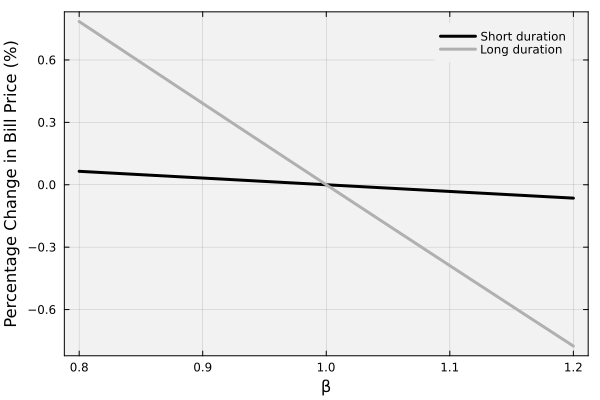

In [17]:
# Plot both maturity responses against the common rate multiplier.
let
        # Compare the short- and long-maturity responses across rate multipliers.
        plot(theorem_2_simulation_array[:,1], theorem_2_simulation_array[:,2], label="Short duration", lw=3, c=:black, 
            xlabel="β", ylabel="Percentage Change in Bill Price (%)")
        plot!(theorem_2_simulation_array[:,1], theorem_2_simulation_array[:,3], label="Long duration", lw=3, c=:gray69, 
            xlabel="β", ylabel="Percentage Change in Bill Price (%)")
        plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

___

## Discussion: Does your simulation result make sense?
If your simulation was implemented correctly, the longer-duration T-bill was more sensitive to changes in the nominal effective discount (interest) rate $y$.

1. Compare the percentage change in the price of the short- and long-duration T-bills at $\beta = 0.9$; the longer-duration instrument should have a larger percentage change in price. Similarly, for $\beta = 1.1$, the price of the longer-duration instrument should show a bigger change relative to the short-duration T-bill.

2. Intuitively, why might you expect __Theorem 2__ to be true?

3. Who is more at risk in a variable interest rate environment, a short-term or long-term bondholder?

___

## Summary

This example combined Treasury-bill auction data with a controlled pricing experiment to study how yield changes affect bills with different terms to maturity.

> __Key Takeaways:__
>
> * __A zero-coupon price is the discounted value of one fixed payment:__ Face value, time to maturity, and the chosen yield convention determine the model price. No other cash flows enter the calculation.
> * __Higher yields reduce T-bill prices:__ Increasing the valuation yield increases the discount applied to the fixed maturity payment. The price therefore moves in the opposite direction from the yield.
> * __Longer maturities amplify interest-rate sensitivity:__ A fixed proportional yield perturbation acts over more time for the longer-maturity bill. The longer bill therefore shows a larger percentage price change than the shorter bill.

The maturity comparison isolates a model mechanism; agreement with auction data additionally requires consistent settlement dates, day counts, and quotation conventions.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance.  Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.